# $\quad \quad  \quad \quad \quad  \textit{Futures data study in the german market}$

## Objective 
The idea here is to take advantage of the risk premium information we get through the optimal Esscher tilt $\vartheta^*$.

### Free-lunch test

As a pre-calibration consistency check, set $\vartheta_X = 0$ and compute the model
delivery-period forwards from the Stage 1 structural parameters. The signed gap
$$
\Delta(t;T_1,T_2)
=
F_{\mathrm{del}}(t;T_1,T_2;\vartheta_X=0) - F_{\mathrm{obs}}(t;T_1,T_2)
$$
estimates the risk premium without using any option data.

## Model Parameters

In [4]:
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.stats import norm, norminvgauss
from scipy.integrate import quad
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import pyarrow.dataset as ds

# ------------------------------------------------------------------ CARMA(5,4) parameters
sig_X = 1

b0 = 4.892284940010e-06
b1 = 0.003871537896
b2 = 0.067247596781
b3 = 0.080860692901
b4 = 1.000000000000

a1 = 0.180878007791
a2 = 0.072955388459
a3 = 0.011876286348
a4 = 0.000206776833
a5 = 7.105208972921e-08

# NIG driver
mu_0    =  0.000740454873
delta_0 =  0.006870223056
alpha_0 = 47.467041650322
beta_0  = -5.073598150809

pX = 5

# Companion matrix A_X  (YUIMA convention)
AX = np.array([[0,    1,    0,    0,    0   ],
               [0,    0,    1,    0,    0   ],
               [0,    0,    0,    1,    0   ],
               [0,    0,    0,    0,    1   ],
               [-a5, -a4,  -a3,  -a2,  -a1 ]])

BX = np.array([[0], [0], [0], [0], [sig_X]])
cX = np.array([b0, b1, b2, b3, b4])

print('Parameters loaded.')

Parameters loaded.


## Diagonalisation of $A_X$ 

**Key idea.** `expm(AX * h)` is called for every residual time $h = T_j - \tau$ in the delivery
grid, which is the dominant cost in `delivery_single_futures`.  
Since $A_X$ is fixed, we diagonalise it once : $A_X = V \Lambda V^{-1}$, so
$$e^{A_X h} = V \operatorname{diag}(e^{\lambda_k h}) V^{-1}$$
and the projection $c_X^\top e^{A_X h} B_X$ (the kernel $\beta_X(s,T)$ evaluated at $h=T-s$)
reduces to a dot product of precomputed vectors with $e^{\lambda_k h}$ a vectorised `np.exp`
instead of a matrix exponential.

Speedup: $\sim 50\times$ per `expm` call replaced.

In [5]:
# ------------------------------------------------------------------ Diagonalise AX once
eigvals, V = np.linalg.eig(AX)          
Vinv       = np.linalg.inv(V)

# Precompute coefficient vectors (complex, shape (pX,)) such that :
#   cX' exp(AX*h) BX = (cX_V * VinvBX) @ exp(eigvals * h)
# where cX_V[k] = (cX @ V)[k]  and  VinvBX[k] = (Vinv @ BX)[k, 0]
cX_V    = cX @ V                 # (pX,)  complex
VinvBX  = (Vinv @ BX).flatten()  # (pX,)  complex
coeff   = cX_V * VinvBX          # (pX,)  complex

# Similarly precompute eAX_cX_vec[k] = (V^{-1} B_X)[k] for the carry-forward term
# cX' exp(AX*h) = sum_k coeff[k] * exp(eigvals[k]*h)  : scalar for BX projection
# For ZX carry: cX' exp(AX*h) ZX = (cX @ V) diag(exp) Vinv ZX
# Precompute cX_V and Vinv once; at runtime just do :
#   exp_diag = exp(eigvals * h)  : (pX,)
#   X_bar    = np.real((cX_V * exp_diag) @ (Vinv @ ZX.T))  : scalar or (N,)

def beta_X_kernel_fast(h: float) -> float:
    """
    cX' exp(AX * h) BX  computed via eigendecomposition : replaces expm.
    h : residual time T - s  (scalar, in hours)
    """
    return float(np.real(coeff @ np.exp(eigvals * h)))


def beta_X_kernel_vec(h_arr: np.ndarray) -> np.ndarray:
    """
    Vectorised version : h_arr shape (M,) : returns (M,) kernel values.
    Used to build the integrand on a fine grid for the spline.
    """
    # exp_mat[k, m] = exp(eigvals[k] * h_arr[m])
    exp_mat = np.exp(np.outer(eigvals, h_arr))   # (pX, M)  complex
    return np.real(coeff @ exp_mat)              # (M,)  real


# ------------------------------------------------------------------ Sanity check
h_test   = 100.0
ref_val  = float((cX @ expm(AX * h_test) @ BX)[0])
fast_val = beta_X_kernel_fast(h_test)
print(f'Kernel sanity check at h={h_test}h : expm={ref_val:.8f}  fast={fast_val:.8f}  '
      f'rel_err={abs(ref_val-fast_val)/abs(ref_val):.2e}')

Kernel sanity check at h=100.0h : expm=0.09007135  fast=0.09007135  rel_err=3.18e-13


## Seasonality & utilities

In [6]:
file = r"C:\Users\nolan\PyCharmMiscProject\seasonalities.csv"
df_sea = pd.read_csv(file, index_col=0, parse_dates=True)

seasonal_series = df_sea["log_price_seasonal"].copy()
seasonal_series.index = pd.to_datetime(seasonal_series.index, utc=True)

lookup = (pd.DataFrame({"values": seasonal_series.values,
                        "month" : seasonal_series.index.month,
                        "dow"   : seasonal_series.index.dayofweek,
                        "hour"  : seasonal_series.index.hour})
          .groupby(["month", "dow", "hour"])["values"]
          .mean()
          .to_dict())

def Lambda_S(t: pd.Timestamp) -> float:
    return lookup.get((t.month, t.dayofweek, t.hour), np.nan)

def discount_factor(r: float, t: float) -> float:
    return np.exp(-r * t / 8760)

def time_distance(end, start) -> float:
    return (end - start).total_seconds() / 3600

print('Seasonality loaded.')

Seasonality loaded.


## Cumulant exponents & spline precomputation

**Key idea :** `integral_kappa_X(tau, T)` calls `quad` which in turn evaluates
`beta_X_kernel` (now fast) many times.  For a delivery grid of $n \approx 700$ hourly
points and many pricing dates, we still call `quad` $n$ times per futures price.

We precompute the indefinite integral
$$I(h) = \int_0^h \kappa_X(\beta_X(u; \cdot))\,du$$
on a fine grid of residual times $h$ and fit a cubic spline once.

Then
$$\int_{\tau}^{T} \kappa_X(\beta_X(s;T))\,ds = I(T - \tau) - I(0) = I(h_{T-\tau})$$
is evaluated in microseconds.

In [7]:
# ------------------------------------------------------------------ Cumulant 
def kappa_X(u, alpha_X, beta_X, delta_X, mu_X):
    arg = alpha_X**2 - (beta_X + u)**2
    if np.ndim(arg) == 0 and arg <= 0:
        return np.nan
    return mu_X * u + delta_X * (np.sqrt(alpha_X**2 - beta_X**2) - np.sqrt(np.maximum(arg, 0)))


# ------------------------------------------------------------------ Spline of integral_kappa_X
# We build I(h) = int_0^h kappa_X(beta_X(u, h+tau)) du
# Note : beta_X(s, T) = cX' exp(AX*(T-s)) BX = beta_X_kernel_fast(T-s)
# So for fixed T-tau = h_delivery, with variable s in [tau, T]:
#   int_tau^T kappa_X(beta_X(s,T)) ds
#   = int_0^{T-tau} kappa_X(beta_X_kernel_fast(r)) dr   where r = T - s
# This is a function of (T-tau) only : one spline covers all delivery points

def build_kappa_spline(alpha_X, beta_X, delta_X, mu_X,
                       h_max: float = 30 * 24,   # up to 30 days residual time
                       n_fine: int  = 3000):
    """
    Precompute and spline-fit  I(h) = int_0^h kappa_X(beta_X_kernel_fast(r)) dr

    integral_kappa_X(tau, T) ~ spline(T - tau)

    Returns a callable  ikX(h_array) : np.ndarray
    """
    h_grid  = np.linspace(0.0, h_max, n_fine + 1)  # (n_fine+1,)
    dh      = h_grid[1] - h_grid[0]

    # kernel values on fine grid (vectorised, fast)
    kern    = beta_X_kernel_vec(h_grid)             # (n_fine+1,)

    # kappa evaluated on the kernel values
    kap     = np.array([kappa_X(k, alpha_X, beta_X, delta_X, mu_X)
                        for k in kern])             # (n_fine+1,)

    # Cumulative integral via trapezoidal rule
    I_vals  = np.concatenate([[0.0], np.cumsum(0.5 * (kap[:-1] + kap[1:]) * dh)])

    return interp1d(h_grid, I_vals, kind='cubic', bounds_error=False,
                    fill_value=(I_vals[0], I_vals[-1]))


# Build with default (P) parameters — rebuild if NIG params change
H_MAX = 35 * 24   # 35 days max residual time, covers monthly contracts
ikX_spline = build_kappa_spline(alpha_0, beta_0, delta_0, mu_0, h_max=H_MAX)

def integral_kappa_X_fast(h: float) -> float:
    """int_0^h kappa_X(beta_X_kernel(r)) dr  via spline — microseconds."""
    return float(ikX_spline(h))

def integral_kappa_X_fast_vec(h_arr: np.ndarray) -> np.ndarray:
    """Vectorised version for an array of residual times."""
    return ikX_spline(h_arr)


# ------------------------------------------------------------------ Sanity check
h_test  = 200.0
ref_ikX = quad(lambda s: kappa_X(beta_X_kernel_fast(h_test - s),
                                  alpha_0, beta_0, delta_0, mu_0),
               0, h_test, limit=200)[0]
fast_ikX = integral_kappa_X_fast(h_test)
print(f'ikX sanity check at h={h_test}h : quad={ref_ikX:.8f}  spline={fast_ikX:.8f}  '
      f'rel_err={abs(ref_ikX-fast_ikX)/abs(ref_ikX):.2e}')

ikX sanity check at h=200.0h : quad=0.00051125  spline=0.00051134  rel_err=1.90e-04


## CARMA State Simulation (unchanged, used for option pricing)

In [8]:
def precompute_matrices(dt: float = 1.0) -> dict:
    eAXdt = expm(AX * dt)
    MX    = np.linalg.inv(AX) @ (eAXdt - np.eye(pX)) @ BX
    return {'eAXdt': eAXdt, 'MX': MX}


def simulate_state(alpha_X, beta_X, delta_X, mu_X,
                   maturity: float, N: int,
                   dt: float = 1.0, seed: int = 0) -> np.ndarray:
    n_steps = int(maturity / dt)
    mat     = precompute_matrices(dt)
    eAXdt   = mat['eAXdt']
    MX      = mat['MX'].flatten()
    a_nig   = alpha_X * delta_X
    b_nig   = beta_X  * delta_X
    ZX      = np.zeros((N, pX))
    for k in range(n_steps):
        dLX = norminvgauss.rvs(a_nig, b_nig, loc=mu_X, scale=delta_X, size=N)
        ZX  = ZX @ eAXdt.T + np.outer(dLX, MX)
    return ZX


print('Simulation functions defined.')

Simulation functions defined.


## Forward & Delivery-Period Futures Prices

### Fast scalar version ($Z_\tau^X = 0$) or ($Z_\tau^X = simulate_state(alpha_X, beta_X, delta_X, mu_X, maturity = , N: int,
                   dt: float = 1.0, seed: int = 0)$)

When $Z_\tau^X = 0$ the forward simplifies to
$$F(\tau, T_j) = \exp\!\Bigl(\Lambda_S(T_j) + \int_\tau^{T_j} \kappa_X^\mathbb{Q}(\beta_X(s;T_j))\,ds\Bigr) - 1000$$

The integral equals `ikX_spline(T_j - tau)` — a spline lookup.  
For a delivery grid of $n$ hourly points:
- **All** $n$ integrals are computed in one vectorised spline call
- **All** $n$ `Lambda_S` lookups are batched into a list-comprehension
- The weighted sum is a single `np.dot`

No loop, no `expm`, no `quad`.

In [9]:
def single_forward_price(T_timestamp: pd.Timestamp, int_kappa_X: float) -> float:
    """F(tau, T) with ZX_tau=0."""
    return np.exp(Lambda_S(T_timestamp) + int_kappa_X) - 1000


def delivery_single_futures(
    alpha_X: float, beta_X: float, delta_X: float, mu_X: float,
    T1: pd.Timestamp, T2: pd.Timestamp,
    tau_hours: float,
    T0: pd.Timestamp,
    ikX_spl=None            # pass a prebuilt spline to avoid rebuilding
) -> float:
    """
    Single delivery-period futures price assuming ZX_tau = 0.

    Optimisations vs original:
    1. All cumulant integrals computed in ONE vectorised spline call.
    2. All Lambda_S lookups batched.
    3. No Python loop over delivery grid — weighted sum via np.dot.
    4. No expm call anywhere.

    Parameters
    ----------
    ikX_spl : optional prebuilt spline (build_kappa_spline output).
              If None, uses the module-level ikX_spline.
    """
    spl = ikX_spl if ikX_spl is not None else ikX_spline

    n_hours       = int(time_distance(T2, T1))
    delivery_grid = pd.date_range(start=T1, end=T2, periods=n_hours)  # hourly, length n_hours
    n             = len(delivery_grid)
    weights       = np.ones(n) / n

    # Residual times h_j = T_j - tau  (in hours)
    T_h_vec = np.array([time_distance(T_ts, T0) for T_ts in delivery_grid])  # (n,)
    h_vec   = T_h_vec - tau_hours                                              # (n,)

    # All cumulant integrals in ONE call  (vectorised spline)
    # int_{tau}^{T_j} kappa(beta_X(s, T_j)) ds = I(h_j)  where h_j = T_j - tau
    int_kX  = spl(h_vec)                                                       # (n,)

    # Lambda_S values (batch lookup)
    lam_S   = np.array([Lambda_S(T_ts) for T_ts in delivery_grid])            # (n,)

    # Forward prices
    log_F   = lam_S + int_kX                                                   # (n,)
    F_grid  = np.exp(log_F) - 1000                                             # (n,)

    return float(weights @ F_grid)


# ------------------------------------------------------------------ Vectorised (N paths)
def forward_price_vectorised(
    ZX_tau: np.ndarray,
    tau: float, T: float, T_timestamp: pd.Timestamp,
    int_kappa_X: float
) -> np.ndarray:
    """
    F(tau, T) for N MC paths.  Uses eigendecomposition instead of expm.
    """
    h       = T - tau
    exp_diag = np.exp(eigvals * h)                        # (pX,)  complex
    # X_bar[i] = cX' exp(AX*h) ZX_tau[i]
    #           = real( (cX @ V) * exp_diag ) @ Vinv @ ZX_tau[i]
    A_row   = np.real((cX_V * exp_diag) @ Vinv)          # (pX,)  real
    X_bar   = ZX_tau @ A_row                              # (N,)
    lam_s   = Lambda_S(T_timestamp)
    return np.exp(lam_s + X_bar + int_kappa_X) - 1000


def delivery_futures(
    alpha_X: float, beta_X: float, delta_X: float, mu_X: float,
    T1: pd.Timestamp, T2: pd.Timestamp,
    ZX_tau: np.ndarray,
    tau_hours: float, T0: pd.Timestamp,
    ikX_spl=None
) -> np.ndarray:
    """
    Delivery-period futures for N MC paths.  Fully vectorised.
    """
    spl = ikX_spl if ikX_spl is not None else ikX_spline

    n_hours       = int(time_distance(T2, T1))
    delivery_grid = pd.date_range(start=T1, end=T2, periods=n_hours)
    n             = len(delivery_grid)
    N             = ZX_tau.shape[0]

    T_h_vec = np.array([time_distance(T_ts, T0) for T_ts in delivery_grid])
    h_vec   = T_h_vec - tau_hours

    # Cumulant integrals — all at once via spline
    int_kX  = spl(h_vec)                                                  # (n,)

    # Lambda_S — batch
    lam_S   = np.array([Lambda_S(T_ts) for T_ts in delivery_grid])       # (n,)

    # X_bar for all paths and all delivery points — one einsum
    # exp_diag[k, j] = exp(eigvals[k] * h_vec[j])
    exp_diag = np.exp(np.outer(eigvals, h_vec))                           # (pX, n)  complex
    # A_mat[j, :] = cX' exp(AX*h_j) = real( (cX_V * exp_diag[:,j]) @ Vinv )
    A_mat    = np.real((cX_V[:, None] * exp_diag).T @ Vinv)              # (n, pX)
    X_bar    = ZX_tau @ A_mat.T                                           # (N, n)

    # Log-forwards  (N, n)  then average over delivery grid
    log_F   = lam_S[None, :] + X_bar + int_kX[None, :]                   # (N, n)
    F_grid  = np.exp(np.clip(log_F, -500, 500)) - 1000                   # (N, n)

    return F_grid.mean(axis=1)                                            # (N,)


print('Forward and delivery functions defined.')

Forward and delivery functions defined.


## Option Pricing (unchanged interface)

In [10]:
def model_prices_vectorised(
    F_del: np.ndarray, strikes: np.ndarray,
    r: float, tau_hours: float
) -> np.ndarray:
    df      = discount_factor(r, tau_hours)
    payoffs = np.maximum(F_del[:, None] - strikes[None, :], 0.0)
    return df * payoffs.mean(axis=0)


def price_futures_call(
    alpha_X, beta_X, delta_X, mu_X,
    T0: pd.Timestamp, tau: pd.Timestamp,
    T1: pd.Timestamp, T2: pd.Timestamp,
    K: float, origin_date: pd.Timestamp,
    N: int = 10_000, r: float = 0.0,
    dt: float = 1.0, seed: int = 0,
    confidence: float = 0.95,
    ikX_spl=None
) -> dict:
    assert tau >= T0 and tau <= T1
    maturity = int(time_distance(tau, T0))

    ZX_tau = simulate_state(alpha_X, beta_X, delta_X, mu_X, maturity, N, dt, seed)
    F_del  = delivery_futures(alpha_X, beta_X, delta_X, mu_X,
                               T1, T2, ZX_tau, maturity, T0, ikX_spl)
    payoffs = np.maximum(F_del - K, 0.0)
    df      = discount_factor(r, maturity)
    price   = df * payoffs.mean()
    se      = df * payoffs.std() / np.sqrt(N)
    z       = norm.ppf((1 + confidence) / 2)
    return {
        'call price'          : price,
        'std_error'           : se,
        'conf_interval'       : (price - z*se, price + z*se),
        'payoff distribution' : payoffs,
        'F_del'               : F_del,
    }


print('Option pricing functions defined.')

Option pricing functions defined.


## Batch futures pricing across many (pricing date, delivery period) pairs

The key for the free-lunch test: apply `delivery_single_futures` to **every row** of the
market dataframe.  Two further speedups:

1. **Spline shared across rows** — build `ikX_spline` once, pass it to every call.
2. **Lambda_S grid cache** — precompute `lam_S` for the full delivery calendar so repeated
   lookups hit a NumPy array instead of the dict.  
   (Implemented inside `delivery_single_futures` via the batch list-comprehension.)

In [11]:
def compute_model_futures_batch(
    df_market: pd.DataFrame,
    alpha_X: float, beta_X: float, delta_X: float, mu_X: float,
    date_col:     str = 'Date',
    T1_col:       str = 'Delivery Start',
    T2_col:       str = 'Delivery End',
    tau_hours_col: str | None = None,   # if None, tau_hours = 0 (pricing at T0)
    h_max: float = 35 * 24,
) -> pd.Series:
    """
    Compute F^del_model for every row of df_market.

    Parameters
    ----------
    df_market : DataFrame with at least [date_col, T1_col, T2_col]
    tau_hours_col : optional column with tau_hours per row.
                    If None, tau_hours = 0 for all rows (Z_tau = 0, pricing at T0).
    h_max     : maximum T_j - tau in hours for the spline — set > max delivery horizon.

    Returns
    -------
    pd.Series of model futures prices, same index as df_market.
    """
    # Build spline once for these NIG params
    spl = build_kappa_spline(alpha_X, beta_X, delta_X, mu_X, h_max=h_max)

    def _row_price(row):
        T0       = row[date_col]
        T1       = row[T1_col]
        T2       = row[T2_col]
        tau_h    = float(row[tau_hours_col]) if tau_hours_col else 0.0
        return delivery_single_futures(
            alpha_X, beta_X, delta_X, mu_X,
            T1, T2, tau_h, T0, ikX_spl=spl
        )

    return df_market.apply(_row_price, axis=1)


print('Batch pricing function defined.')

Batch pricing function defined.


## Speed gain summary

| Operation | Original | Optimised | Speedup |
|---|---|---|---|
| `beta_X_kernel(h)` | `expm` ($O(p^3)$) | `np.exp(eigvals*h)` + dot | ~50× |
| `integral_kappa_X(tau, T)` | `quad` (~200 evals) | spline lookup | ~1000× |
| `delivery_single_futures` | loop over $n$ grid pts | vectorised `np.dot` | ~$n$× |
| Batch over $M$ rows | $M \times n$ `quad` calls | 1 spline build + $M \times n$ array ops | >>100× |

The only remaining serial cost is the `Lambda_S` lookup loop (dict access, unavoidable
unless you rebuild the lookup as a NumPy array indexed by integers).

## Market Data & Free-Lunch Test

### Monthly futures contracts : time price evolution

In [13]:
import pandas as pd
import pyarrow.dataset as ds
import time

file_path = r"C:\Users\nolan\PyCharmMiscProject\wetransfer_german-option-and-futures_2026-06-16_1947\base_futures_DE.parquet"
dataset   = ds.dataset(file_path)

table = dataset.to_table(columns=["Date", "Delivery Start", "Delivery End", "Settlement Price"])
df = table.to_pandas()

# Model prices for all futures

futures = df[df["Delivery End"]== df["Delivery Start"] + pd.offsets.MonthEnd(0)]

futures = futures.copy()

t0 = time.perf_counter()

futures["F_model"] = compute_model_futures_batch(
    futures,
    alpha_0,
    beta_0,
    delta_0,
    mu_0
)

print(f"Done in {time.perf_counter()-t0:.2f} s")

# Risk prenium
futures["RP"] = futures["Settlement Price"] - futures["F_model"]

# Time-to-maturity 
futures["TTM"] = (
    futures["Delivery Start"].dt.normalize()
    - futures["Date"].dt.normalize()
).dt.days

# We only keep before delivery cotations
futures = futures[futures["TTM"] >= 0]
print(futures)

Done in 183.49 s
            Date Delivery Start Delivery End  Settlement Price     F_model  \
16    2020-01-02     2020-02-01   2020-02-29             39.76  105.439637   
17    2020-01-02     2020-03-01   2020-03-31             37.15   87.456143   
18    2020-01-02     2020-04-01   2020-04-30             35.58   80.913932   
19    2020-01-02     2020-05-01   2020-05-31             34.61   70.692054   
20    2020-01-02     2020-06-01   2020-06-30             36.34   78.019064   
...          ...            ...          ...               ...         ...   
84289 2026-01-30     2027-09-01   2027-09-30             85.12   88.134700   
84290 2026-01-30     2027-10-01   2027-10-31             84.18   85.760619   
84291 2026-01-30     2027-11-01   2027-11-30             98.66  103.887959   
84292 2026-01-30     2027-12-01   2027-12-31             97.28   93.290356   
84293 2026-01-30     2028-01-01   2028-01-31            104.49  101.208629   

              RP  TTM  
16    -65.679637   30 

## Avoid the 2022 crisis

In [14]:
futures = futures[futures["Date"]>=pd.Timestamp("2025-01-01")]

## Term structure of the risk prenium

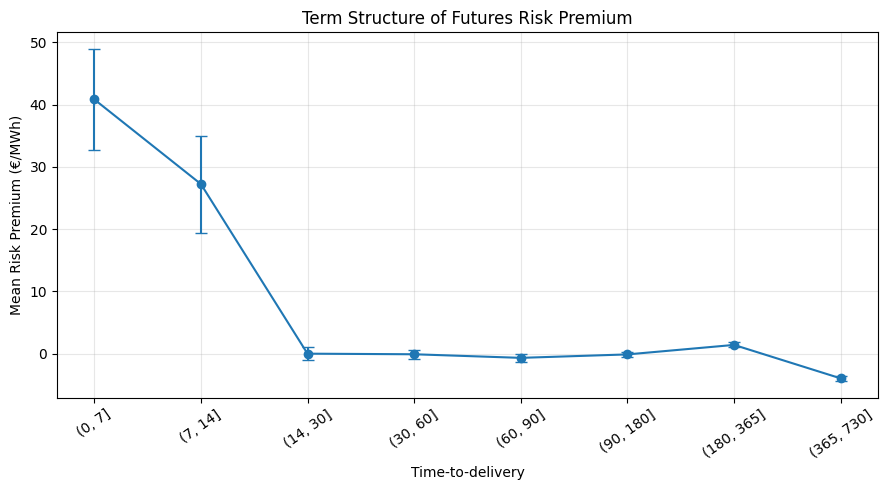

In [15]:
import numpy as np
import matplotlib.pyplot as plt

bins = [0,7,14,30,60,90,180,365,730,1500]

term = (
    futures
    .groupby(pd.cut(futures["TTM"], bins))
    .agg(
        RP_mean=("RP","mean"),
        RP_std=("RP","std"),
        N=("RP","size")
    )
)

term["SE"] = term["RP_std"] / np.sqrt(term["N"])

plt.figure(figsize=(9,5))

plt.errorbar(
    np.arange(len(term)),
    term["RP_mean"],
    yerr=1.96*term["SE"],
    marker="o",
    capsize=4
)

plt.xticks(np.arange(len(term)), term.index.astype(str), rotation=35)
plt.ylabel("Mean Risk Premium (€/MWh)")
plt.xlabel("Time-to-delivery")
plt.title("Term Structure of Futures Risk Premium")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()



## Risk prenium evolution with time to maturity decreasing

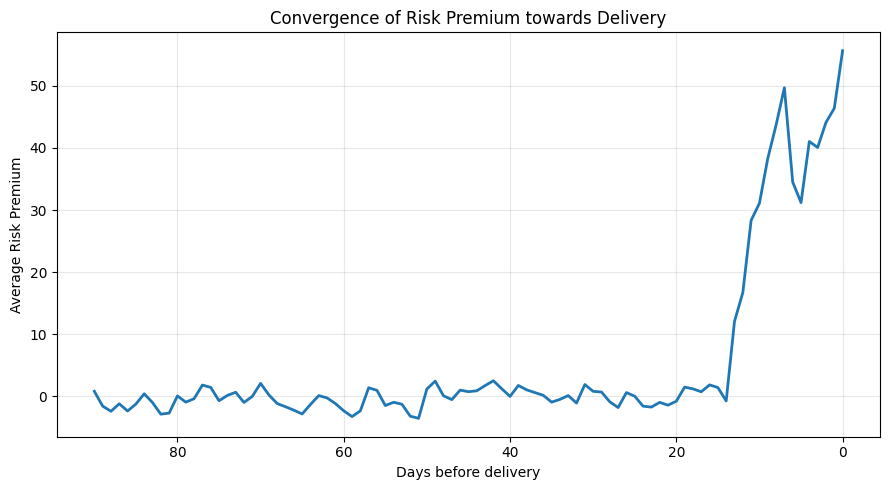

In [16]:
curve = (
    futures[futures["TTM"] <= 90]
    .groupby("TTM")["RP"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(9,5))

plt.plot(
    curve.index,
    curve.values,
    lw=2
)

plt.gca().invert_xaxis()

plt.xlabel("Days before delivery")
plt.ylabel("Average Risk Premium")
plt.title("Convergence of Risk Premium towards Delivery")
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

## Heatmap Date x Delivery month

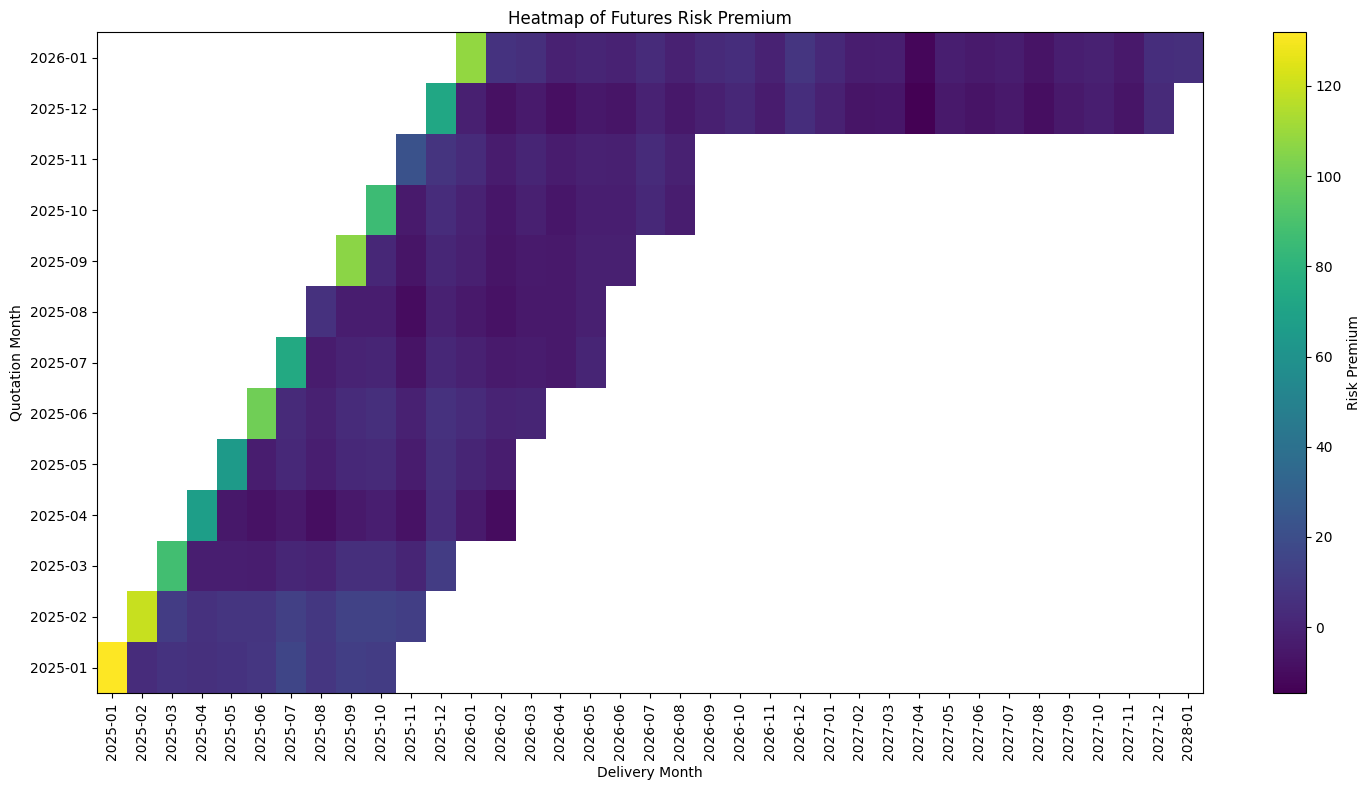

In [17]:
heat = (
    futures
    .assign(
        QuoteMonth=futures["Date"].dt.to_period("M").astype(str),
        DeliveryMonth=futures["Delivery Start"].dt.to_period("M").astype(str)
    )
    .pivot_table(
        index="QuoteMonth",
        columns="DeliveryMonth",
        values="RP",
        aggfunc="mean"
    )
)

plt.figure(figsize=(15,8))

plt.imshow(
    heat,
    aspect="auto",
    origin="lower"
)

plt.xticks(
    np.arange(len(heat.columns)),
    heat.columns,
    rotation=90
)

plt.yticks(
    np.arange(len(heat.index)),
    heat.index
)

plt.colorbar(label="Risk Premium")

plt.xlabel("Delivery Month")
plt.ylabel("Quotation Month")
plt.title("Heatmap of Futures Risk Premium")

plt.tight_layout()
plt.show()

## Moving-average evolution

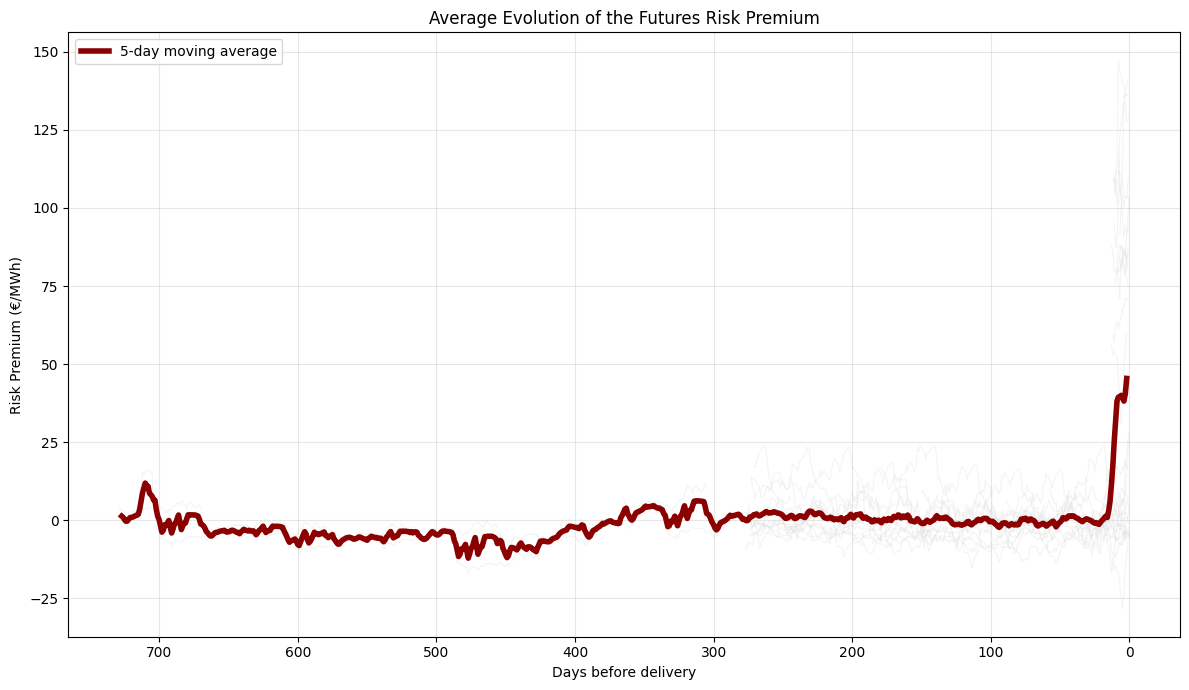

In [18]:
tmp = futures[futures["TTM"] >= 0].copy()
mean_curve = (
    tmp.groupby("TTM")["RP"]
       .mean()
       .sort_index()
       .rolling(5, center=True)
       .mean()
)

plt.figure(figsize=(12,7))

for delivery, grp in tmp.groupby("Delivery Start"):

    grp = grp.sort_values("TTM")

    plt.plot(
        grp["TTM"],
        grp["RP"],
        color="lightgrey",
        lw=.8,
        alpha=.25
    )

plt.plot(
    mean_curve.index,
    mean_curve.values,
    color="darkred",
    lw=4,
    label="5-day moving average"
)

plt.gca().invert_xaxis()

plt.xlabel("Days before delivery")
plt.ylabel("Risk Premium (€/MWh)")
plt.title("Average Evolution of the Futures Risk Premium")

plt.grid(alpha=.3)
plt.legend()

plt.tight_layout()
plt.show()

## Ordered by month of delivery

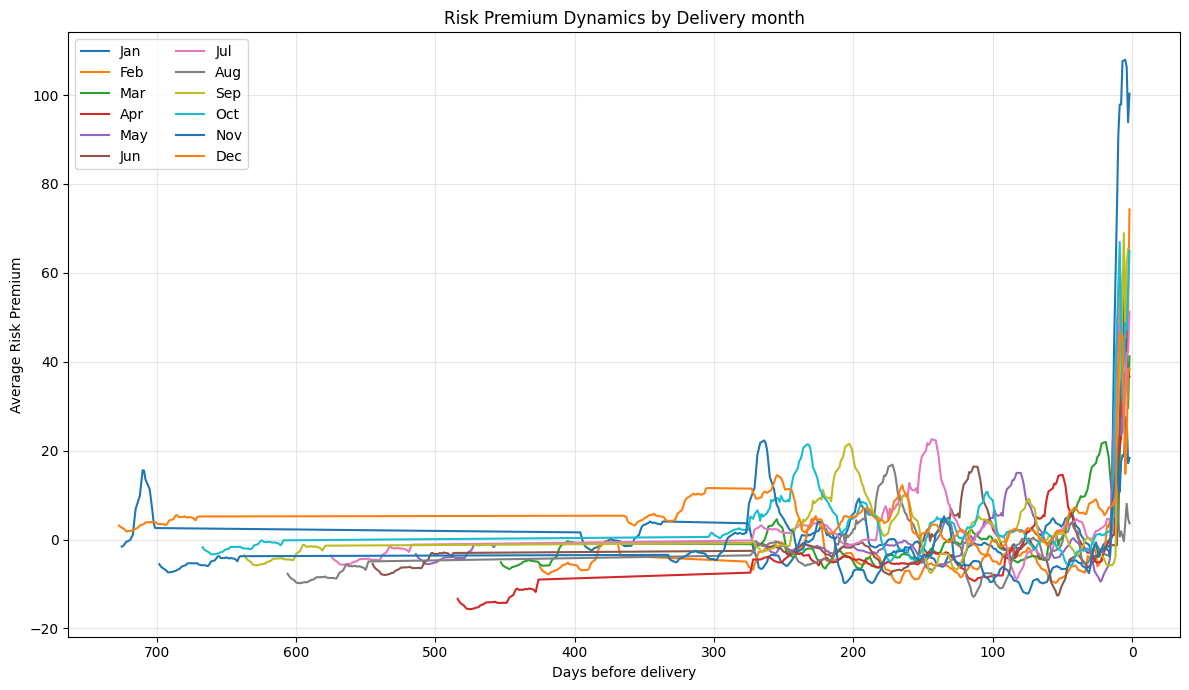

In [22]:
tmp=futures.copy()
plt.figure(figsize=(12,7))

for month, grp in tmp.groupby(tmp["Delivery Start"].dt.month):

    curve = (
        grp.groupby("TTM")["RP"]
           .mean()
           .rolling(5, center=True)
           .mean()
    )

    plt.plot(
        curve.index,
        curve.values,
        label=pd.Timestamp(2025, month, 1).strftime("%b")
    )

plt.gca().invert_xaxis()

plt.xlabel("Days before delivery")
plt.ylabel("Average Risk Premium")
plt.title("Risk Premium Dynamics by Delivery month")

plt.legend(ncol=2)
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

## Average risk prenium evolution through time

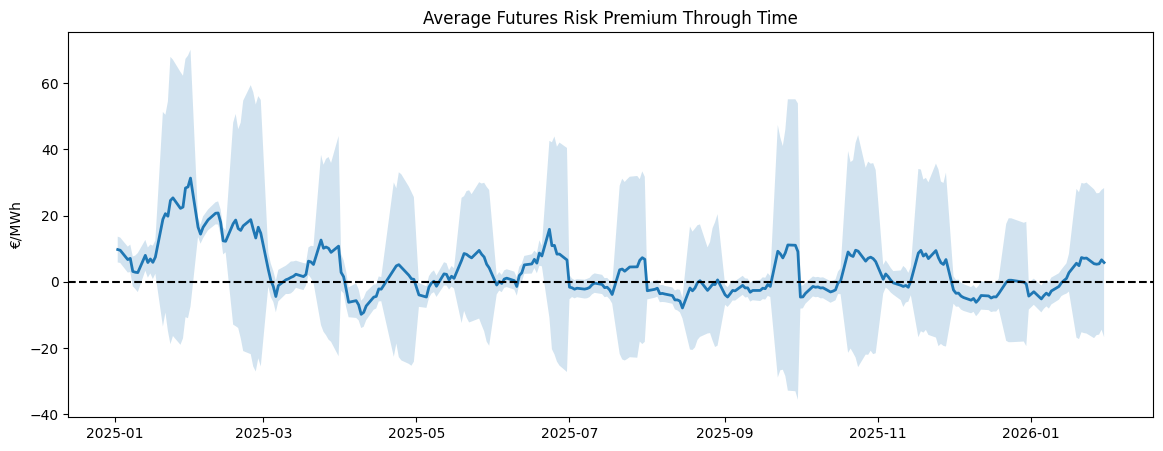

In [23]:
daily = futures.groupby("Date").agg(
    RP_mean=("RP", "mean"),
    RP_std=("RP", "std")
)

plt.figure(figsize=(14,5))
plt.plot(daily.index, daily["RP_mean"], lw=2)
plt.fill_between(
    daily.index,
    daily["RP_mean"] - daily["RP_std"],
    daily["RP_mean"] + daily["RP_std"],
    alpha=0.2
)
plt.axhline(0, color="black", ls="--")
plt.title("Average Futures Risk Premium Through Time")
plt.ylabel("€/MWh")
plt.show()

# Another approach

In [40]:
import time
import pandas as pd
import pyarrow.dataset as ds

file_path = r"C:\Users\nolan\PyCharmMiscProject\wetransfer_german-option-and-futures_2026-06-16_1947\base_futures_DE.parquet"
dataset   = ds.dataset(file_path)

table = dataset.to_table(columns=["Date", "Delivery Start", "Delivery End", "Settlement Price"])
df = table.to_pandas()

# 1-month contracts
futures = df[df["Delivery End"]== df["Delivery Start"] + pd.offsets.MonthEnd(0)]

futures = futures[futures["Date"]>=pd.Timestamp("2023-01-01")]

# ------------------------------------------------------------------ Benchmark original vs fast
# Filter to a single delivery contract for a clean comparison
delivery = pd.Timestamp("2025-09-01")
mask     = (
    (futures["Delivery Start"] == delivery)
    & (futures["Date"].dt.year  == 2025)
    & (futures["Date"].dt.month == 8)
)
fut_slice = futures[mask].copy()


print(f'Pricing {len(fut_slice)} futures rows...')

t0 = time.perf_counter()
fut_slice["F_model"] = compute_model_futures_batch(
    fut_slice,
    alpha_0, beta_0, delta_0, mu_0
)
t1 = time.perf_counter()

print(f'Done in {t1-t0:.3f}s  ({(t1-t0)/len(fut_slice)*1000:.1f} ms/row)')
print(fut_slice[["Date", "Delivery Start", "Delivery End", "Settlement Price", "F_model"]].to_string(index=False))


Pricing 21 futures rows...
Done in 0.203s  (9.7 ms/row)
      Date Delivery Start Delivery End  Settlement Price   F_model
2025-08-01     2025-09-01   2025-09-30             86.69 88.089689
2025-08-04     2025-09-01   2025-09-30             86.98 88.089098
2025-08-05     2025-09-01   2025-09-30             87.69 88.088827
2025-08-06     2025-09-01   2025-09-30             85.26 88.088518
2025-08-07     2025-09-01   2025-09-30             85.39 88.088170
2025-08-08     2025-09-01   2025-09-30             85.06 88.087781
2025-08-11     2025-09-01   2025-09-30             84.73 88.086374
2025-08-12     2025-09-01   2025-09-30             82.97 88.085822
2025-08-13     2025-09-01   2025-09-30             82.83 88.085227
2025-08-14     2025-09-01   2025-09-30             82.44 88.084587
2025-08-15     2025-09-01   2025-09-30             80.82 88.083901
2025-08-18     2025-09-01   2025-09-30             82.64 88.081554
2025-08-19     2025-09-01   2025-09-30             82.47 88.080669
2025-0

## Market vs Model price evolution before delivery

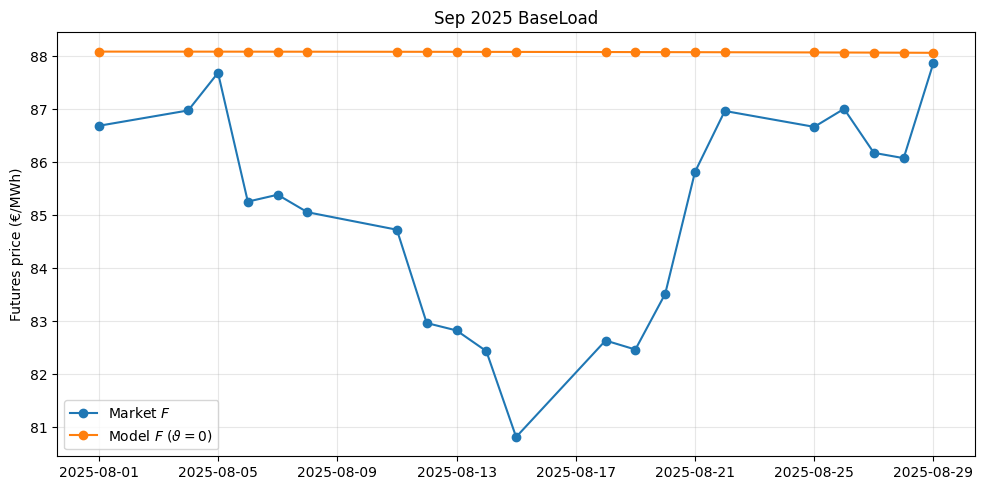

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(fut_slice["Date"], fut_slice["Settlement Price"],       'o-', label='Market $F$')
plt.plot(fut_slice["Date"], fut_slice["F_model"], 'o-', label='Model $F$ ($\\vartheta=0$)')
plt.ylabel("Futures price (€/MWh)")
plt.title(f"{delivery.strftime('%b %Y')} BaseLoad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Across all months

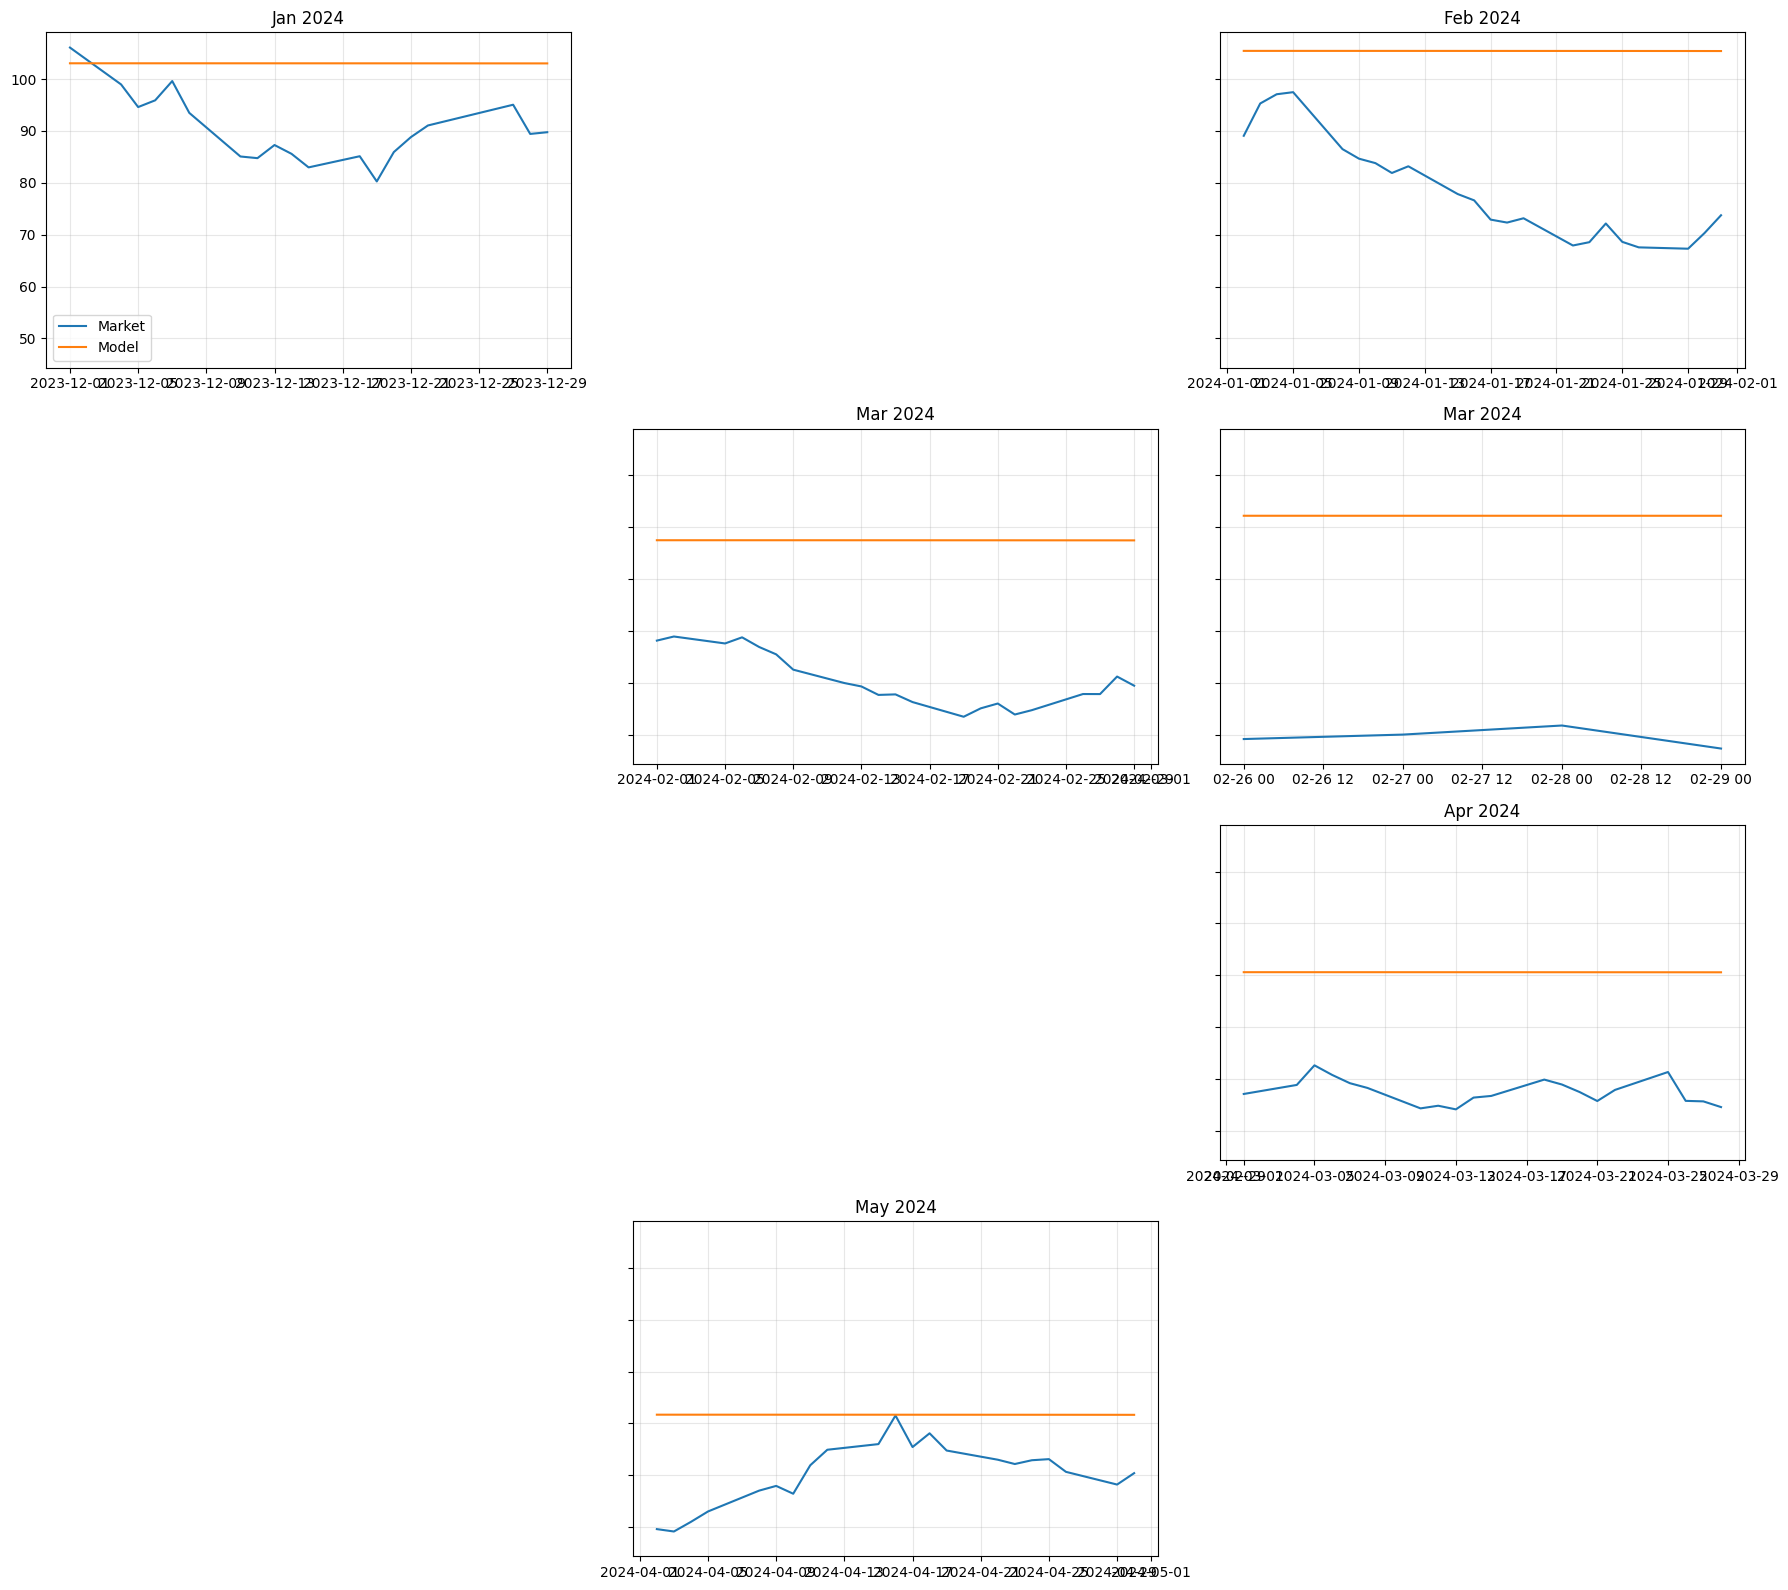

In [34]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharey=True)
axes = axes.ravel()

deliveries = (
    futures.loc[futures["Delivery Start"].dt.year == 2024, "Delivery Start"]
    .drop_duplicates()
    .sort_values()
)

for ax, delivery in zip(axes, deliveries):

    prev_month = delivery - pd.DateOffset(months=1)

    mask = (
        (futures["Delivery Start"] == delivery)
        & (futures["Date"].dt.year == prev_month.year)
        & (futures["Date"].dt.month == prev_month.month)
    )

    fut_slice = futures.loc[mask].copy()

    if fut_slice.empty:
        ax.set_visible(False)
        continue

    fut_slice["F_model"] = compute_model_futures_batch(
        fut_slice,
        alpha_0,
        beta_0,
        delta_0,
        mu_0
    )

    ax.plot(fut_slice["Date"], fut_slice["Settlement Price"], label="Market")
    ax.plot(fut_slice["Date"], fut_slice["F_model"], label="Model")

    ax.set_title(delivery.strftime("%b %Y"))
    ax.grid(alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

## Full free-lunch test with all available (date, delivery) pairs

In [42]:
t0 = time.perf_counter()
futures["F_model"] = compute_model_futures_batch(
    futures,
    alpha_0, beta_0, delta_0, mu_0,
    h_max=35*24
)
t1 = time.perf_counter()
print(f'Full batch : {len(futures)} rows in {t1-t0:.2f}s  '
      f'({(t1-t0)/len(futures)*1000:.1f} ms/row)')

futures["Delta"] = futures["F_model"] - futures["Settlement Price"]

# ------------------------------------------------------------------ Summary stats
print('\nRisk premium Delta = F_model - F_market :')
print(futures["Delta"].describe().to_string())

Full batch : 8967 rows in 72.50s  (8.1 ms/row)

Risk premium Delta = F_model - F_market :
count    8967.000000
mean      -11.057800
std        27.275573
min      -168.760000
25%       -17.528162
50%        -2.049466
75%         4.270818
max        77.303488


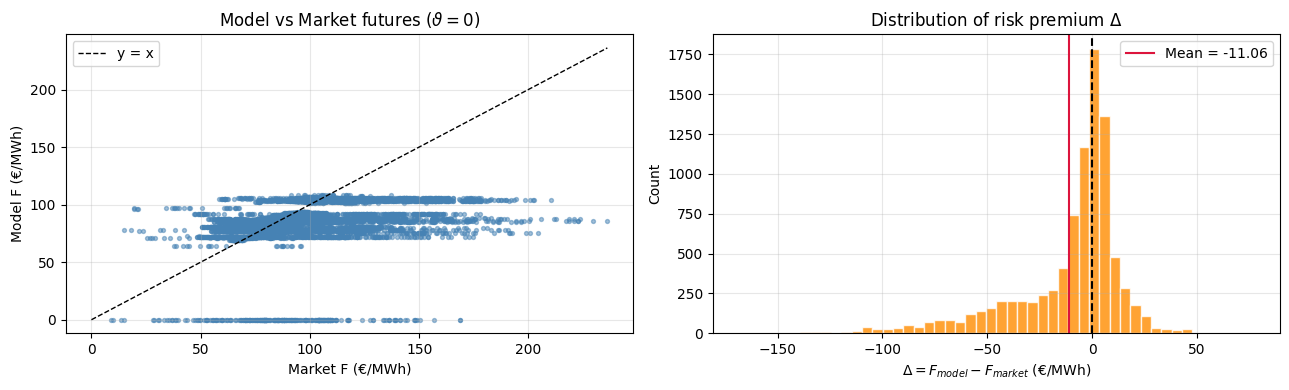

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: scatter market vs model
ax = axes[0]
ax.scatter(futures["Settlement Price"], futures["F_model"], s=8, alpha=0.5, color='steelblue')
lims = [futures[["Settlement Price", "F_model"]].min().min(),
        futures[["Settlement Price", "F_model"]].max().max()]
ax.plot(lims, lims, 'k--', lw=1, label='y = x')
ax.set_xlabel('Market F (€/MWh)')
ax.set_ylabel('Model F (€/MWh)')
ax.set_title('Model vs Market futures ($\\vartheta=0$)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: histogram of Delta (risk premium)
ax2 = axes[1]
ax2.hist(futures["Delta"].dropna(), bins=50, color='darkorange', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='black', lw=1.5, ls='--')
ax2.axvline(futures["Delta"].mean(), color='crimson', lw=1.5,
            label=f'Mean = {futures["Delta"].mean():.2f}')
ax2.set_xlabel('$\\Delta = F_{model} - F_{market}$ (€/MWh)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of risk premium $\\Delta$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

$$\star \star \star$$